채널: 임영웅
영상: 15살 나이 차이 나는 형 동생__nkE-YmRUIpM
텍스트: '아 진짜…' (5자)
crop 크기: 139x47

[원본 crop]


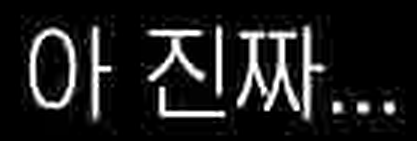


[이진화 crop]


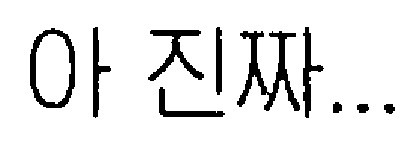


비교 대상 폰트 파일: 1213개


폰트 비교:   0%|          | 0/1213 [00:00<?, ?it/s]


텔롭 텍스트: '아 진짜…'
비교 완료: 1202개 폰트

Top 20:
  순위     IoU                             폰트 weight
   1  0.6720                 RixInooAriDuri    400
   2  0.6624                      GasoekOne    400
   3  0.6525             ChangwonDangamAsac    700
   4  0.6516              KBLJump-Condensed    800
   5  0.6259                      Dallawang    700
   6  0.6175                           chab    400
   7  0.6173             Hakgyoansim-Puzzle    900
   8  0.6129               KBLJump-Extended    800
   9  0.6041                        OKDDUNG    400
  10  0.5915                           TMON    900
  11  0.5899               PyeongChangPeace    700
  12  0.5844                     TTTogether    400
  13  0.5820                        RiaSans    800
  14  0.5708                      KERISKEDU    700
  15  0.5696                      Dallawang    400
  16  0.5686                   BlackHanSans    400
  17  0.5653                 RixYeoljeongdo    400
  18  0.5629                      DNFBit

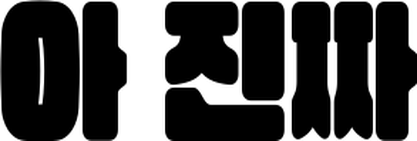

  [렌더링 이진화]


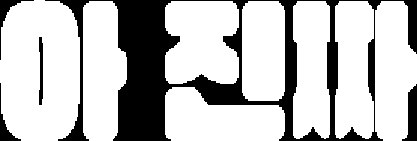

  [차이: 흰=겹침, 빨강=crop만, 파랑=렌더만]


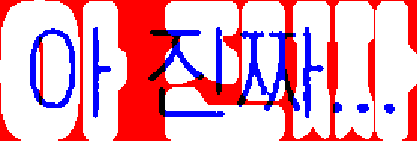

In [7]:
import os
import json
import glob
import random
import numpy as np
import pandas as pd
import cv2
from PIL import Image, ImageFont, ImageDraw
from tqdm.auto import tqdm
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rc('font', family='NanumGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

FRAME_DIR = "./data/2_frame_files"
OCR_DIR = "./data/3_ocr_results"
INST_DIR = "./data/6_telop_instances"
FONT_DIR = "./fonts/ttf"
FPS = 10

EXCLUDE = {
    '116angduk_honesty', '116angmuburi', '116watermelon', 'BusanFont',
    'CAChildrenKkum', 'CAChildrenModu', 'Cafe24PROUP', 'Chilgok_Kaj',
    'DOSPilgi', 'Danjo', 'DaehwaNanum-sound', 'Diphylleia',
    'Gilbeot_Rainbow', 'KCC-Ahnjunggeun', 'KCC-BangJeonghwan', 'KJDcom',
    'NationalLibrary', 'PartialSans', 'PeachMarket', 'gabia-solmee',
    'locus_sangsang', 'tillvictorycomes',
}

# ── 1) 텔롭 있는 영상 랜덤 선택 + crop ──
channels = sorted([d for d in os.listdir(INST_DIR) if os.path.isdir(os.path.join(INST_DIR, d))])

found = False
for _ in range(100):
    channel = random.choice(channels)
    ch_dir = os.path.join(INST_DIR, channel)
    videos_list = sorted([f for f in os.listdir(ch_dir) if f.endswith(".json")])
    video = random.choice(videos_list)
    video_name = video.replace(".json", "")

    inst_path = os.path.join(INST_DIR, channel, video)
    ocr_path = os.path.join(OCR_DIR, channel, f"{video_name}.parquet")
    frame_dir = os.path.join(FRAME_DIR, channel, video_name)

    if not os.path.exists(ocr_path) or not os.path.exists(frame_dir):
        continue

    with open(inst_path, "r") as f:
        instances = json.load(f).get("instances", [])

    candidates = [inst for inst in instances if len(inst["text"]) >= 3]
    if not candidates:
        continue

    inst = candidates[len(candidates) // 2]
    mid_sec = (inst["start_sec"] + inst["end_sec"]) / 2
    mid_frame = int(mid_sec * FPS) + 1

    df_ocr = pd.read_parquet(ocr_path)
    frame_row = df_ocr[df_ocr["frame_num"] == mid_frame]
    if frame_row.empty:
        for offset in range(1, 5):
            for try_frame in [mid_frame + offset, mid_frame - offset]:
                frame_row = df_ocr[df_ocr["frame_num"] == try_frame]
                if not frame_row.empty:
                    mid_frame = try_frame
                    break
            if not frame_row.empty:
                break
    if frame_row.empty:
        continue

    row = frame_row.iloc[0]
    texts = json.loads(row["ocr_texts"]) if isinstance(row["ocr_texts"], str) else row["ocr_texts"]
    xywhas = json.loads(row["ocr_xywha"]) if isinstance(row["ocr_xywha"], str) else row["ocr_xywha"]

    match_idx = None
    for i, t in enumerate(texts):
        if t == inst["text"]:
            match_idx = i
            break
    if match_idx is None:
        for i, t in enumerate(texts):
            if inst["text"] in t or t in inst["text"]:
                match_idx = i
                break
    if match_idx is None:
        continue

    frame_path = os.path.join(frame_dir, f"frame_{mid_frame:08d}.jpg")
    if not os.path.exists(frame_path):
        continue

    found = True
    break

if not found:
    raise ValueError("100회 시도 내에 유효한 영상을 찾지 못함")

# ── 2) crop + 이진화 (2x upscale + K-means K=3 글자+외곽선 + opening(3)) ──
bbox = xywhas[match_idx]
frame_img = Image.open(frame_path)
cx, cy, w, h, angle = bbox
x1 = max(0, int(cx - w / 2))
y1 = max(0, int(cy - h / 2))
x2 = min(frame_img.width, int(cx + w / 2))
y2 = min(frame_img.height, int(cy + h / 2))

crop = frame_img.crop((x1, y1, x2, y2))
crop_np = np.array(crop)
target_h, target_w = crop_np.shape[:2]
target_text = inst["text"]
scale = 3

print(f"채널: {channel}")
print(f"영상: {video_name}")
print(f"텍스트: '{target_text}' ({len(target_text)}자)")
print(f"crop 크기: {target_w}x{target_h}\n")

print("[원본 crop]")
display(Image.fromarray(crop_np).resize((target_w * scale, target_h * scale), Image.LANCZOS))

crop_up = cv2.resize(crop_np, (target_w * 2, target_h * 2), interpolation=cv2.INTER_LANCZOS4)
up_h, up_w = crop_up.shape[:2]

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
pixels_up = crop_up.reshape(-1, 3).astype(np.float32)
_, labels_up, centers_up = cv2.kmeans(pixels_up, 3, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
labels_up = labels_up.reshape(up_h, up_w)

cb_up = [np.mean(centers_up[i]) for i in range(3)]
sc_up = np.argsort(cb_up)
bin_up = np.isin(labels_up, sc_up[:2]).astype(np.uint8) * 255

kernel3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
crop_bin = cv2.morphologyEx(bin_up, cv2.MORPH_OPEN, kernel3)

print("\n[이진화 crop]")
display(Image.fromarray(crop_bin).resize((target_w * scale, target_h * scale), Image.NEAREST))

# ── 3) 모든 폰트로 동일 텍스트 렌더링 + IoU 비교 ──
font_files = sorted(glob.glob(os.path.join(FONT_DIR, "*.ttf")))
usable = []
for path in font_files:
    fname = os.path.splitext(os.path.basename(path))[0]
    parts = fname.rsplit("-", 1)
    if len(parts) != 2 or not parts[1].isdigit():
        continue
    if parts[0] not in EXCLUDE:
        usable.append({"path": path, "font_name": parts[0], "weight": int(parts[1])})

print(f"\n비교 대상 폰트 파일: {len(usable)}개")

results = []
for font_info in tqdm(usable, desc="폰트 비교"):
    try:
        font = ImageFont.truetype(font_info["path"], 100)
        tmp_img = Image.new("L", (2000, 500), 255)
        tmp_draw = ImageDraw.Draw(tmp_img)
        tmp_draw.text((0, 0), target_text, fill=0, font=font)

        tmp_np = np.array(tmp_img)
        rows = np.any(tmp_np < 128, axis=1)
        cols = np.any(tmp_np < 128, axis=0)
        if not rows.any() or not cols.any():
            continue
        rmin, rmax = np.where(rows)[0][[0, -1]]
        cmin, cmax = np.where(cols)[0][[0, -1]]
        rendered_crop = tmp_np[rmin:rmax+1, cmin:cmax+1]

        rendered_resized = cv2.resize(rendered_crop, (up_w, up_h), interpolation=cv2.INTER_LANCZOS4)
        rendered_bin = (rendered_resized < 128).astype(np.uint8) * 255

        crop_fg = crop_bin == 255
        rend_fg = rendered_bin == 255
        intersection = np.sum(crop_fg & rend_fg)
        union = np.sum(crop_fg | rend_fg)
        iou = intersection / union if union > 0 else 0

        results.append({
            "font_name": font_info["font_name"],
            "weight": font_info["weight"],
            "iou": iou,
        })
    except Exception:
        continue

# ── 4) 결과 정렬 ──
results.sort(key=lambda x: x["iou"], reverse=True)

print(f"\n{'='*60}")
print(f"텔롭 텍스트: '{target_text}'")
print(f"비교 완료: {len(results)}개 폰트")
print(f"\nTop 20:")
print(f"{'순위':>4} {'IoU':>7} {'폰트':>30} {'weight':>6}")
for i, r in enumerate(results[:20]):
    print(f"{i+1:>4} {r['iou']:>7.4f} {r['font_name']:>30} {r['weight']:>6}")

# ── 5) Top 1 시각적 비교 ──
r = results[0]
font_path = os.path.join(FONT_DIR, f"{r['font_name']}-{r['weight']}.ttf")
font = ImageFont.truetype(font_path, 100)
tmp_img = Image.new("L", (2000, 500), 255)
tmp_draw = ImageDraw.Draw(tmp_img)
tmp_draw.text((0, 0), target_text, fill=0, font=font)

tmp_np = np.array(tmp_img)
rows = np.any(tmp_np < 128, axis=1)
cols = np.any(tmp_np < 128, axis=0)
rmin, rmax = np.where(rows)[0][[0, -1]]
cmin, cmax = np.where(cols)[0][[0, -1]]
rendered_crop = tmp_np[rmin:rmax+1, cmin:cmax+1]

rendered_orig = Image.fromarray(rendered_crop).resize((target_w * scale, target_h * scale), Image.LANCZOS)

rendered_resized = cv2.resize(rendered_crop, (up_w, up_h), interpolation=cv2.INTER_LANCZOS4)
rendered_bin = (rendered_resized < 128).astype(np.uint8) * 255
rendered_bin_img = Image.fromarray(rendered_bin).resize((target_w * scale, target_h * scale), Image.NEAREST)

xor_diff = np.zeros((up_h, up_w, 3), dtype=np.uint8)
crop_fg = crop_bin == 255
rend_fg = rendered_bin == 255
xor_diff[crop_fg & rend_fg] = [255, 255, 255]
xor_diff[crop_fg & ~rend_fg] = [255, 0, 0]
xor_diff[rend_fg & ~crop_fg] = [0, 0, 255]
xor_img = Image.fromarray(xor_diff).resize((target_w * scale, target_h * scale), Image.NEAREST)

print(f"\n#1 {r['font_name']}-{r['weight']} (IoU: {r['iou']:.4f})")
print("  [렌더링]")
display(rendered_orig)
print("  [렌더링 이진화]")
display(rendered_bin_img)
print("  [차이: 흰=겹침, 빨강=crop만, 파랑=렌더만]")
display(xor_img)